1. Mount Google Drive

In [ ]:
!git clone https://github.com/heathclif-cyber/Riset_pemodelan.git

%cd /workspace/Riset_pemodelan

In [7]:
!pip install -q \
    lightgbm \
    torch \
    scikit-learn \
    shap \
    pyarrow \
    joblib \
    pandas \
    numpy \
    pickleshare \
    matplotlib


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [5]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

CUDA: True
Device: NVIDIA RTX 4000 Ada Generation


In [8]:
%cd /workspace/Riset_pemodelan

/workspace/Riset_pemodelan


In [13]:
# Fetch 15 koin tambahan
# Estimasi waktu: 1-2 jam
!python pipeline/01_fetch.py --all --reset

2026-04-25 15:31:58 | INFO     | 01_fetch | ============================================================
2026-04-25 15:31:58 | INFO     | 01_fetch |   FETCH DATA: ALL COINS (Jan 2022 → Apr 2025)
2026-04-25 15:31:58 | INFO     | 01_fetch |   Koin     : ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT']
2026-04-25 15:31:58 | INFO     | 01_fetch |   Periode  : 2022-01-01 → 2025-04-01
2026-04-25 15:31:58 | INFO     | 01_fetch | ============================================================
2026-04-25 15:31:58 | INFO     | 01_fetch | Progress di-reset.
2026-04-25 15:31:58 | INFO     | 01_fetch | Koneksi Binance OK.
2026-04-25 15:31:58 | INFO     | 01_fetch | 
--- FETCH MACRO DATA ---
2026-04-25 15:31:58 | INFO     | fetchers | =======================================================
2026-04-25 15:31:58 | INFO     | fetchers | FETCH MA

In [15]:
!sed -i 's|https://fapi.binance.com|https://data-api.binance.vision|g' /workspace/Riset_pemodelan/config.py

In [16]:
import os
files = list(os.walk('data/raw/klines'))
for root, dirs, fs in files[:5]:
    print(root, len(fs), 'files')

data/raw/klines 0 files
data/raw/klines/ARBUSDT 3 files
data/raw/klines/TAOUSDT 3 files
data/raw/klines/1000PEPEUSDT 3 files
data/raw/klines/NEARUSDT 3 files


In [17]:
!python pipeline/02_clean.py --all

2026-04-25 15:35:36 | INFO     | 02_clean | [SOLUSDT] Starting cleaning...
2026-04-25 15:35:36 | INFO     | 02_clean | [SOLUSDT] 1h: 28,464 rows, 0 gaps
2026-04-25 15:35:36 | INFO     | 02_clean | [SOLUSDT] 4h: 7,116 rows, 0 gaps
2026-04-25 15:35:36 | INFO     | 02_clean | [SOLUSDT] 1d: 1,186 rows, 0 gaps
2026-04-25 15:35:36 | INFO     | 02_clean | [SOLUSDT] Saved → /workspace/Riset_pemodelan/data/processed/SOLUSDT_clean.parquet (28,464 rows × 31 cols)
2026-04-25 15:35:36 | INFO     | 02_clean | [ETHUSDT] Starting cleaning...
2026-04-25 15:35:36 | INFO     | 02_clean | [ETHUSDT] 1h: 28,464 rows, 0 gaps
2026-04-25 15:35:36 | INFO     | 02_clean | [ETHUSDT] 4h: 7,116 rows, 0 gaps
2026-04-25 15:35:36 | INFO     | 02_clean | [ETHUSDT] 1d: 1,186 rows, 0 gaps
2026-04-25 15:35:36 | INFO     | 02_clean | [ETHUSDT] Saved → /workspace/Riset_pemodelan/data/processed/ETHUSDT_clean.parquet (28,464 rows × 31 cols)
2026-04-25 15:35:36 | INFO     | 02_clean | [BNBUSDT] Starting cleaning...
2026-04-25 

In [30]:
!grep -n "calc_ofi_features\|calc_vwdp\|calc_vsa" /workspace/Riset_pemodelan/core/features.py

In [42]:
!python pipeline/03_engineer.py --all

2026-04-25 16:26:14 | INFO     | 03_engineer | [SOLUSDT] Starting feature engineering v3...
2026-04-25 16:26:32 | INFO     | features | [SOLUSDT] Swing-Based labeling v3 (max_hold=48h, min_rr=1.5, min_tp=1.5×ATR, max_sl=3.0×ATR)...
2026-04-25 16:26:32 | INFO     | features | Structural filter: 179 LONG → FLAT, 185 SHORT → FLAT
2026-04-25 16:26:32 | INFO     | features | [SOLUSDT] Label distribution v3: LONG=2164 (7.6%), SHORT=2339 (8.2%), FLAT=23961 (84.2%)
2026-04-25 16:26:32 | INFO     | features | [SOLUSDT] Features v3: 28,464 rows × 86 cols | NaN: 2.7%
2026-04-25 16:26:33 | INFO     | 03_engineer | [SOLUSDT] Saved 28451 rows to SOLUSDT_features_v3.parquet
2026-04-25 16:26:33 | INFO     | 03_engineer | [ETHUSDT] Starting feature engineering v3...
2026-04-25 16:26:51 | INFO     | features | [ETHUSDT] Swing-Based labeling v3 (max_hold=48h, min_rr=1.5, min_tp=1.5×ATR, max_sl=3.0×ATR)...
2026-04-25 16:26:51 | INFO     | features | Structural filter: 192 LONG → FLAT, 200 SHORT → FLAT
202

In [43]:
!python pipeline/analyze_min_hold.py --save-plot

[INFO] LABEL_DIR      = /workspace/Riset_pemodelan/data/labeled
[INFO] MAX_HOLDING_BARS = 48
  Loading 1000PEPEUSDT...
    16,699 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 2,706 entries LONG/SHORT | median=4h | p10=2h
  Loading 1000SHIBUSDT...
    28,451 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 4,694 entries LONG/SHORT | median=4h | p10=2h
  Loading ADAUSDT...
    28,451 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 4,550 entries LONG/SHORT | median=4h | p10=2h
  Loading AVAXUSDT...
    28,451 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 4,365 entries LONG/SHORT | median=3h | p10=2h
  Loading BNBUSDT...
    28,451 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 4,661 entries LONG/SHORT | median=4h | p10

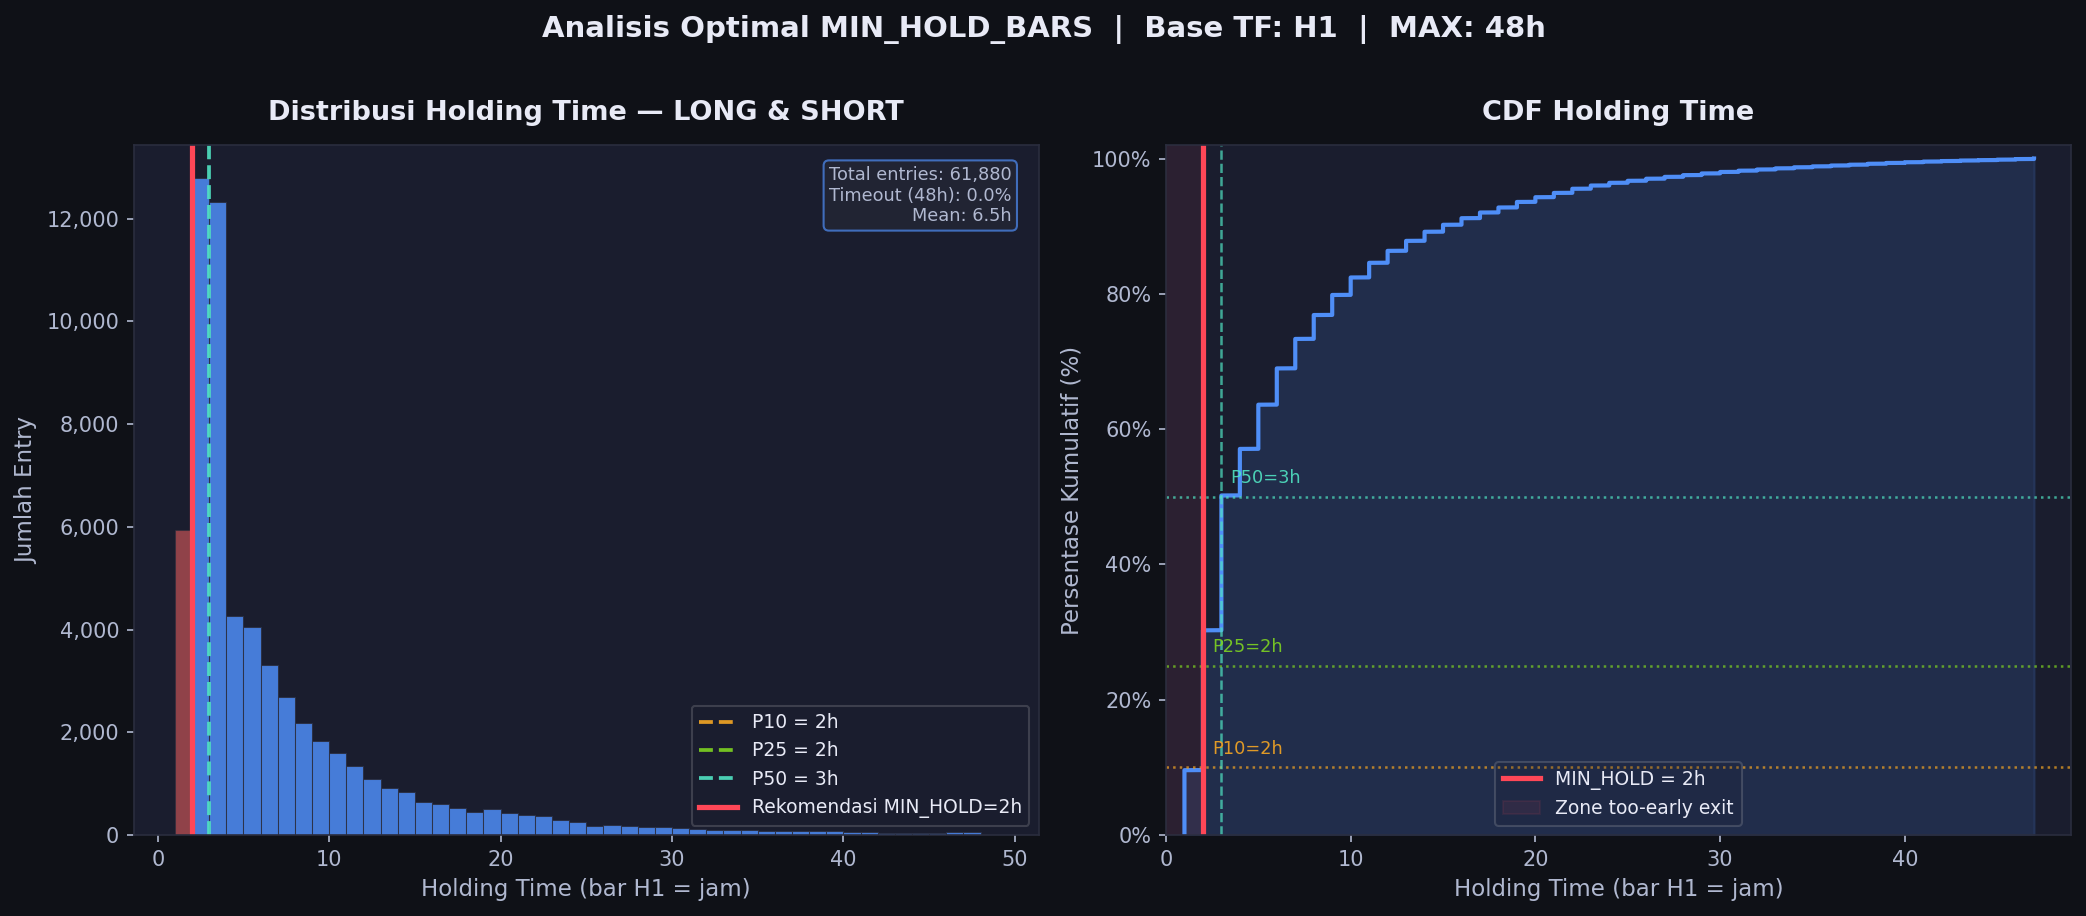

In [44]:
from IPython.display import Image

# Gunakan absolute path RunPod
Image("/workspace/Riset_pemodelan/reports/min_hold_analysis.png")

In [ ]:
# Fase 04: Latih H4 LGBM (Regime Filter)
# Bias gate: menentukan apakah market sedang LONG/SHORT/FLAT di TF H4
# Estimasi waktu: 15-30 menit
!python pipeline/04_train_lgbm_h4.py --all

In [ ]:
# Fase 05: Latih H1 LGBM (Entry Signal Generator)
# Cost-sensitive class weights: SHORT=3x, FLAT=1x, LONG=3x
# Estimasi waktu: 15-30 menit
!python pipeline/05_train_lgbm_h1.py --all

In [46]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX 4000 Ada Generation


In [ ]:
# Fase 06: Latih LSTM (Momentum Confirmation Vote)
# LSTM berperan sebagai konfirmasi akhir cascade sebelum sinyal diterbitkan
# Estimasi waktu: 30-60 menit (GPU T4 direkomendasikan)
!python pipeline/06_train_lstm.py --all

In [ ]:
# NOTE: Meta-learner (06_ensemble.py) sudah DIHAPUS dari arsitektur.
#
# Arsitektur baru: Hierarchical Decision Cascade
#   STEP 1  04_train_lgbm_h4.py -> H4 LGBM bias (LONG / SHORT / FLAT)
#   STEP 2  05_train_lgbm_h1.py -> H1 LGBM entry probability
#   STEP 3  06_train_lstm.py    -> LSTM confirmation vote
#   STEP 4  Decision layer      -> sinyal diterbitkan jika ketiga sepakat
#
# Logic cascade ada di: pipeline/backtest_utils.py (hierarchical_predict)
#                   dan: swint_tradev2/app/services/inference.py
print("Hierarchical Cascade aktif. Tidak ada ensemble step. Lanjut ke Fase 07.")

In [56]:
!grep "def " /workspace/Riset_pemodelan/core/evaluator.py

def simulate_trades(
def simulate_trades_swing(
def calc_drawdown(equity_curve: list, modal_per_trade: float = 1000.0) -> dict:
def calc_consecutive_loss(pnl_per_trade: list) -> int:
def calc_trade_per_month(total_trades: int, index: pd.DatetimeIndex) -> float:
def full_trading_report(
    def run_sim(lev):


In [57]:
import json
from pathlib import Path

registry = {
    "active": "hierarchical_cascade",
    "architecture": "Hierarchical Decision Cascade (H4 LGBM → H1 LGBM → LSTM)",
    "models": {
        "h4_lgbm": {
            "version": "v3",
            "role": "Regime Filter (binary: LONG/SHORT/FLAT)",
            "status": "active",
            "f1_macro": None,
            "winrate": None,
            "trade_per_month": None,
            "pnl_lev5x": None,
            "max_drawdown": None,
            "max_consecutive_loss": None,
            "trained_date": None,
        },
        "h1_lgbm": {
            "version": "v3",
            "role": "Entry Signal Generator (3-class: SHORT/FLAT/LONG)",
            "status": "active",
            "f1_macro": None,
            "winrate": None,
            "trade_per_month": None,
            "pnl_lev5x": None,
            "max_drawdown": None,
            "max_consecutive_loss": None,
            "trained_date": None,
        },
        "lstm": {
            "version": "v3",
            "role": "Momentum Confirmation Vote",
            "status": "active",
            "f1_macro": None,
            "winrate": None,
            "trade_per_month": None,
            "pnl_lev5x": None,
            "max_drawdown": None,
            "max_consecutive_loss": None,
            "trained_date": None,
        }
    }
}

path = Path("/workspace/Riset_pemodelan/models/model_registry.json")
path.parent.mkdir(parents=True, exist_ok=True)
with open(path, "w") as f:
    json.dump(registry, f, indent=2)

print("model_registry.json created")

model_registry.json created


In [58]:
!python pipeline/07_evaluate.py

2026-04-25 17:01:43 | INFO     | 07_evaluate | Model loaded: /workspace/Riset_pemodelan/models/lgbm_baseline.pkl
2026-04-25 17:01:43 | INFO     | 07_evaluate | Feature cols v2 loaded: 85 fitur
2026-04-25 17:01:44 | INFO     | 07_evaluate | SHAP calculation: 10,000 samples × 85 features

  TOP-20 FEATURES (Mean |SHAP|) — SOLUSDT
  Rank  Feature                       Mean |SHAP|
  ----  ----------------------------  -----------
     1  ema_7_h4                         0.845248
     2  price_in_range                   0.595546
     3  Sell_Liq                         0.569794
     4  rsi_h4                           0.521808
     5  Buy_Liq                          0.496587
     6  ema_7_h1                         0.189145
     7  swing_momentum                   0.177324
     8  log_ret_5                        0.135897
     9  rsi_6                            0.135716
    10  time_to_funding_norm             0.135265
    11  trend_strength                   0.135213
    12  dist_swing_l

In [59]:
!python pipeline/08_backtest.py --all

2026-04-25 17:02:32 | INFO     | 08_backtest | Models loaded | Device: cuda | Features: 85 | Coins: ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT']
2026-04-25 17:02:32 | INFO     | 08_backtest | [SOLUSDT] Loaded: 28,451 rows
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 1 done — test=3,157 bars
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 2 done — test=3,156 bars
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 3 done — test=3,156 bars
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 4 done — test=3,156 bars
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 5 done — test=3,156 bars
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 6 done — test=3,156 bars
2026-04-25 17:02:33 | INFO     | 08_backtest | [SOLUSDT] Fold 7 done — test=3,156 bars
2

In [61]:
!python pipeline/09_holdout_backtest.py --all


  HOLD-OUT BACKTEST — holdout_20260425_170352
  Periode : 2025-05-01 → 2026-04-01
  Koin    : ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT']

2026-04-25 17:03:52 | INFO     | 09_holdout_backtest | === STEP 1: FETCH HOLD-OUT DATA ===
2026-04-25 17:03:53 | INFO     | 09_holdout_backtest | Binance OK | Periode: 2025-05-01 → 2026-04-01
2026-04-25 17:03:53 | INFO     | fetchers | =======================================================
2026-04-25 17:03:53 | INFO     | fetchers | FETCH MACRO DATA
2026-04-25 17:03:53 | INFO     | fetchers | =======================================================
2026-04-25 17:03:53 | INFO     | fetchers | Fetching Fear & Greed Index dari alternative.me...
2026-04-25 17:03:54 | INFO     | fetchers | Fear & Greed disimpan: 321 hari → /workspace/Riset_pemodelan/data/raw/macro/fear_greed_index.parque

In [ ]:
!python pipeline/10_visualize.py --all --holdout --verify-swing

/workspace/Riset_pemodelan/core/models.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(path), map_location=device)
2026-04-25 17:08:58 | INFO    